# Proyek Klasifikasi Gambar: Fruit and Vegetable Disease (Healthy vs Rotten)
- **Nama:** Gesang Nur Zamroji
- **Email:** gesang.23145@mhs.unesa.ac.id - m284d5y0685@student.devacademy.id
- **ID Dicoding:** M284D5Y0685

## Import Semua Packages/Library yang Digunakan

In [2]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from sklearn.utils import compute_class_weight


## Data Preparation

### Data Loading

In [3]:

BASE_PATH = '/kaggle/input/fruit-and-vegetable-disease-healthy-vs-rotten/Fruit And Vegetable Diseases Dataset'
NEW_PATH_SPLIT = '/kaggle/working/Split_Dataset_Fruit_Vegetable_6class'

TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15


selected_classes = [
    'Apple__Healthy',
    'Apple__Rotten',
    'Banana__Healthy',
    'Banana__Rotten',
    'Bellpepper__Healthy',
    'Bellpepper__Rotten'
]

def split_data(source_dir, train_dir, val_dir, test_dir, split_ratio):
    files = [f for f in os.listdir(source_dir)
             if os.path.isfile(os.path.join(source_dir, f))]
    
    random.shuffle(files)
    
    train_count = int(len(files) * split_ratio['train'])
    val_count = int(len(files) * split_ratio['val'])
    
    train_files = files[:train_count]
    val_files = files[train_count:train_count + val_count]
    test_files = files[train_count + val_count:]

    for f in train_files:
        shutil.copy(os.path.join(source_dir, f), os.path.join(train_dir, f))
    for f in val_files:
        shutil.copy(os.path.join(source_dir, f), os.path.join(val_dir, f))
    for f in test_files:
        shutil.copy(os.path.join(source_dir, f), os.path.join(test_dir, f))

if os.path.exists(NEW_PATH_SPLIT):
    print(f"Dataset sudah dibagi sebelumnya di folder {NEW_PATH_SPLIT}.")
else:
    print(f"Membuat direktori baru: {NEW_PATH_SPLIT}")
    os.makedirs(NEW_PATH_SPLIT)

    # Loop hanya kelas terpilih
    for class_name in selected_classes:

        os.makedirs(os.path.join(NEW_PATH_SPLIT, 'train', class_name), exist_ok=True)
        os.makedirs(os.path.join(NEW_PATH_SPLIT, 'validation', class_name), exist_ok=True)
        os.makedirs(os.path.join(NEW_PATH_SPLIT, 'test', class_name), exist_ok=True)

        source = os.path.join(BASE_PATH, class_name)
        split_data(
            source_dir=source,
            train_dir=os.path.join(NEW_PATH_SPLIT, 'train', class_name),
            val_dir=os.path.join(NEW_PATH_SPLIT, 'validation', class_name),
            test_dir=os.path.join(NEW_PATH_SPLIT, 'test', class_name),
            split_ratio={'train': TRAIN_SPLIT, 'val': VAL_SPLIT, 'test': TEST_SPLIT}
        )
print("Proses pembagian dataset berhasil")


Membuat direktori baru: /kaggle/working/Split_Dataset_Fruit_Vegetable_6class
Proses pembagian dataset berhasil


### Data Preprocessing

#### Split Dataset

In [4]:
train_dir = '/kaggle/working/Split_Dataset_Fruit_Vegetable_6class/train'
validation_dir = '/kaggle/working/Split_Dataset_Fruit_Vegetable_6class/validation'
test_dir = '/kaggle/working/Split_Dataset_Fruit_Vegetable_6class/test'

In [30]:
import os
import pandas as pd
class_names = os.listdir(train_dir)
data_summary = []

for class_name in class_names:
    train_count = len(os.listdir(os.path.join(train_dir, class_name)))
    val_count = len(os.listdir(os.path.join(validation_dir, class_name)))
    test_count = len(os.listdir(os.path.join(test_dir, class_name)))
    total_count = train_count + val_count + test_count
    data_summary.append([class_name, train_count, val_count, test_count, total_count])

df_summary = pd.DataFrame(data_summary, columns=['Class', 'Train', 'Validation', 'Test', 'Total'])
total_row = df_summary[['Train', 'Validation', 'Test', 'Total']].sum()
total_row['Class'] = 'Total'
df_summary = pd.concat([df_summary, pd.DataFrame([total_row])], ignore_index=True)
df_summary


,Class,Train,Validation,Test,Total
0,Bellpepper__Healthy,427,91,93,611
1,Apple__Healthy,1706,365,367,2438
2,Apple__Rotten,2051,439,440,2930
3,Banana__Healthy,1400,300,300,2000
4,Banana__Rotten,1959,420,421,2800
5,Bellpepper__Rotten,413,88,90,591
6,Total,7956,1703,1711,11370


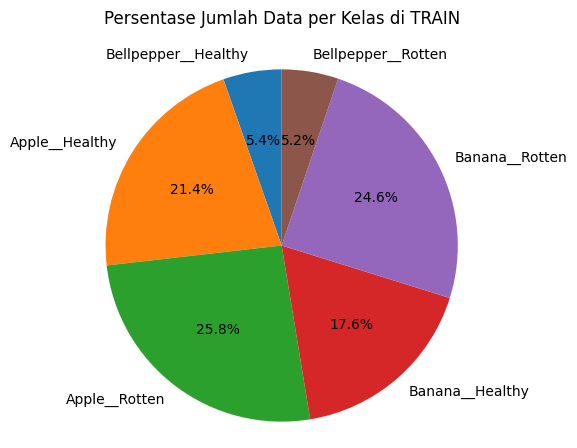

In [32]:
import matplotlib.pyplot as plt

train_counts = df_summary.set_index('Class')['Train'][:-1]  
plt.figure(figsize=(5,5))
plt.pie(train_counts, labels=train_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Persentase Jumlah Data per Kelas di TRAIN\n')
plt.axis('equal')  
plt.show()


In [5]:
print("================ PREPROCESSING & AUGMENTATION ==================")
IMG_SIZE = 224  
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=False,   
    brightness_range=[0.9, 1.1],
    channel_shift_range=10,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
class_labels = list(train_generator.class_indices.keys())



================ PREPROCESSING & AUGMENTATION ==================
Found 7950 images belonging to 6 classes.
Found 1701 images belonging to 6 classes.
Found 1710 images belonging to 6 classes.


## Modelling

In [8]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2


base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    layers.Input((IMG_SIZE, IMG_SIZE, 3)),
    
    base_model,

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),  

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation='softmax')
], name='Fruit_Vegetable_classification')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "Fruit_Vegetable_classification"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │     1,474,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,750,470 (14.31 MB)

 Trainable params: 1,492,230 (5.69 MB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [9]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',patience=5,mode='max',restore_best_weights=True,verbose=1,min_delta=0.0
    ),

    ModelCheckpoint(
        '/kaggle/working/best_model.keras',monitor='val_accuracy',save_best_only=True,mode='max',verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',factor=0.5,patience=5,min_lr=1e-7,verbose=1
    )
]


In [10]:
class_weights = compute_class_weight(class_weight='balanced',classes=np.unique(train_generator.classes),y=train_generator.classes)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights :\n {class_weight_dict}")


Class weights :
 {0: 0.7766705744431418, 1: 0.6472887151929653, 2: 0.9464285714285714, 3: 0.6770567194685744, 4: 3.1030444964871196, 5: 3.208232445520581}


In [11]:
EPOCHS = 10

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=callbacks,
    class_weight = class_weight_dict,
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1764691093.360467     138 service.cc:148] XLA service 0x79ff20012670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764691093.361136     138 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764691093.361156     138 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764691094.300847     138 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/249 ━━━━━━━━━━━━━━━━━━━━ 48:05 12s/step - accuracy: 0.3125 - loss: 2.0765

I0000 00:00:1764691099.463550     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.8680 - loss: 0.4252
Epoch 1: val_accuracy improved from -inf to 0.96767, saving model to /kaggle/working/best_model.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 159s 596ms/step - accuracy: 0.8682 - loss: 0.4245 - val_accuracy: 0.9677 - val_loss: 0.0920 - learning_rate: 0.0010
Epoch 2/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.9686 - loss: 0.1029
Epoch 2: val_accuracy did not improve from 0.96767
249/249 ━━━━━━━━━━━━━━━━━━━━ 136s 545ms/step - accuracy: 0.9686 - loss: 0.1029 - val_accuracy: 0.9630 - val_loss: 0.0926 - learning_rate: 0.0010
Epoch 3/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.9745 - loss: 0.0761
Epoch 3: val_accuracy improved from 0.96767 to 0.97884, saving model to /kaggle/working/best_model.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 136s 547ms/step - accuracy: 0.9745 - loss: 0.0761 - val_accuracy: 0.9788 - val_loss: 0.0639 - learning_rate: 0.0010
Epoch 4/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step 

## Evaluasi dan Visualisasi

In [12]:
print("========== EVALUASI TRAIN ===========")
train_loss, train_acc = model.evaluate(train_generator, verbose=1)
print(f"Train Accuracy: {train_acc*100:.2f}%")

print("========== EVALUASI VAL ===========")
val_loss, val_acc = model.evaluate(validation_generator, verbose=1)
print(f"Val Accuracy: {val_acc*100:.2f}%")

print("========== EVALUASI TEST ===========")
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Val Accuracy: {test_acc*100:.2f}%")

========== EVALUASI TRAIN ===========
249/249 ━━━━━━━━━━━━━━━━━━━━ 128s 513ms/step - accuracy: 0.9967 - loss: 0.0097
Train Accuracy: 99.56%
========== EVALUASI VAL ===========
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.9891 - loss: 0.0398
Val Accuracy: 98.59%
========== EVALUASI TEST ===========
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.9850 - loss: 0.0415
Val Accuracy: 98.42%


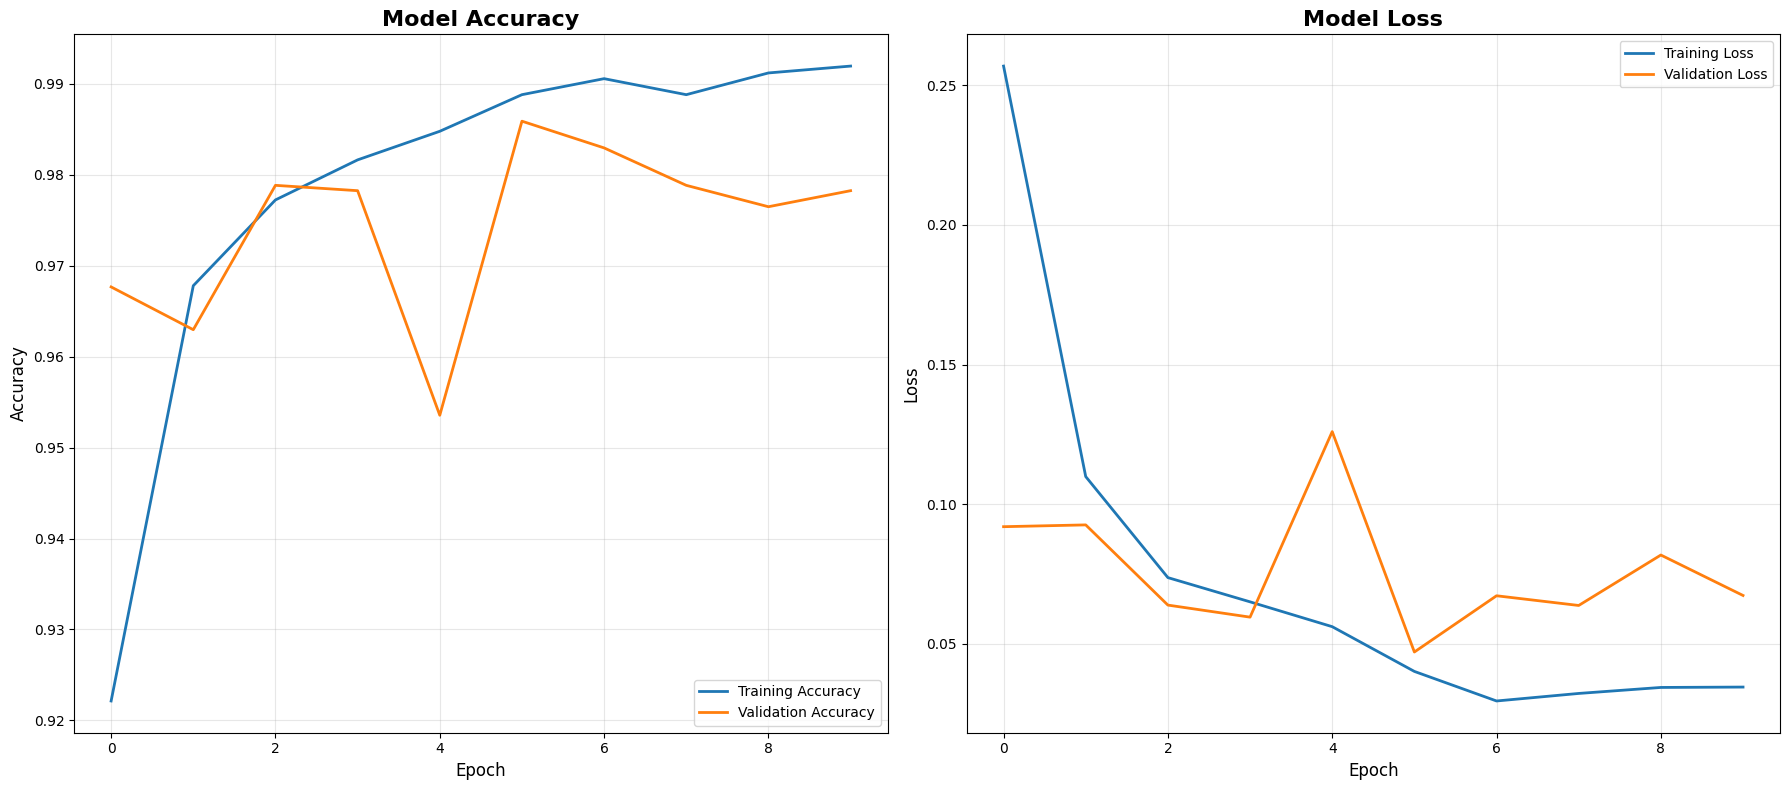

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=16, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss', fontsize=16, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Konversi Model

In [14]:
import os

root_dir = "submission"

# 1. SavedModel 
saved_model_dir = os.path.join(root_dir, "saved_model")
model.export(saved_model_dir)
print(f"SavedModel saved to: {saved_model_dir}/")

INFO:tensorflow:Assets written to: submission/saved_model/assets


INFO:tensorflow:Assets written to: submission/saved_model/assets


Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_317')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  134139546843472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134139816805776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134139816804816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134139816805584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134139816804624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134139816807312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134139816807696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134139816808080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134139816807888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134139816805008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1341

In [15]:
tflite_dir = os.path.join(root_dir, "tflite")
os.makedirs(tflite_dir, exist_ok=True)

saved_model_dir = os.path.join(root_dir, "saved_model")
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
tflite_model = converter.convert()
tflite_path = os.path.join(tflite_dir, "model.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_model)
print(f"TFLite saved to: {tflite_path}")


# label.txt
class_labels = list(train_generator.class_indices.keys())
label_path = os.path.join(tflite_dir, "label.txt")
with open(label_path, "w") as f:
    for label in class_labels:
        f.write(label + "\n")
print(f"label.txt saved to: {label_path}")


TFLite saved to: submission/tflite/model.tflite
label.txt saved to: submission/tflite/label.txt


W0000 00:00:1764692629.406674      47 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1764692629.406714      47 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1764692629.556881      47 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


In [18]:

tfjs_dir = os.path.join(root_dir, "tfjs_model")
os.makedirs(tfjs_dir, exist_ok=True)

!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    submission/saved_model \
    submission/tfjs_model

print("TFJS model converted to:", tfjs_dir)


2025-12-02 16:26:26.360432: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764692786.379960     498 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764692786.385829     498 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
🌲 Try https://ydf.readthedocs.io, the successor of TensorFlow Decision Forests with more features and faster training!
I0000 00:00:1764692792.819882     498 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11778 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764692792.820558     498 gpu_device.cc:2022] Created device /job:localhost/replica:0

In [28]:
!zip -r submission_export.zip submission
print("ZIP created: submission_export.zip")


updating: submission/ (stored 0%)
updating: submission/tfjs_model/ (stored 0%)
updating: submission/tfjs_model/group1-shard3of4.bin (deflated 7%)
updating: submission/tfjs_model/group1-shard4of4.bin (deflated 7%)
updating: submission/tfjs_model/group1-shard1of4.bin (deflated 7%)
updating: submission/tfjs_model/model.json (deflated 97%)
updating: submission/tfjs_model/group1-shard2of4.bin (deflated 7%)
updating: submission/saved_model/ (stored 0%)
updating: submission/saved_model/variables/ (stored 0%)
updating: submission/saved_model/variables/variables.index (deflated 78%)
updating: submission/saved_model/variables/variables.data-00000-of-00001 (deflated 7%)
updating: submission/saved_model/saved_model.pb (deflated 91%)
updating: submission/saved_model/fingerprint.pb (stored 0%)
updating: submission/saved_model/assets/ (stored 0%)
updating: submission/tflite/ (stored 0%)
updating: submission/tflite/model.tflite (deflated 7%)
updating: submission/tflite/label.txt (deflated 47%)
  addin

## Inference (Optional)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


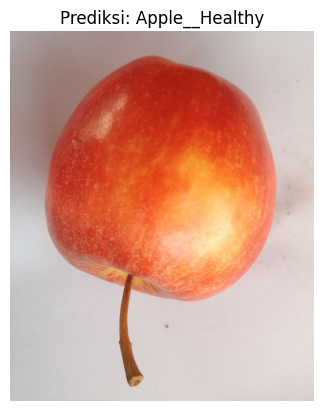

In [22]:

tflite_path = "/kaggle/working/submission/tflite/model.tflite"
label_path = "/kaggle/working/submission/tflite/label.txt"
with open(label_path, "r") as f:
    labels = [line.strip() for line in f]

interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

IMG_SIZE = 224

def predict_tflite(image_path):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((IMG_SIZE, IMG_SIZE))

    input_data = np.array(img_resized, dtype=np.float32)
    input_data = input_data / 255.0
    input_data = np.expand_dims(input_data, axis=0)

    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]['index'])
    pred_idx = np.argmax(output[0])
    pred_label = labels[pred_idx]

    return img, pred_label
img_path = "/kaggle/working/Split_Dataset_Fruit_Vegetable_6class/test/Apple__Healthy/FreshApple (100).jpg"

img, pred = predict_tflite(img_path)

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediksi: {pred}")
plt.show()



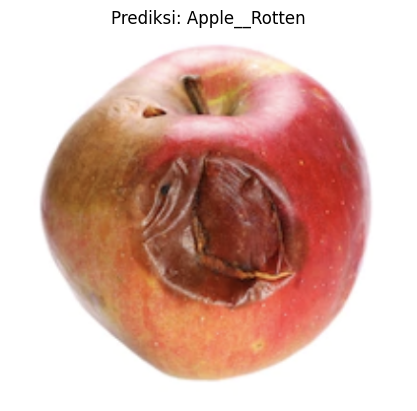

In [26]:

tflite_path = "/kaggle/working/submission/tflite/model.tflite"
label_path = "/kaggle/working/submission/tflite/label.txt"
with open(label_path, "r") as f:
    labels = [line.strip() for line in f]

interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

IMG_SIZE = 224

def predict_tflite(image_path):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((IMG_SIZE, IMG_SIZE))

    input_data = np.array(img_resized, dtype=np.float32)
    input_data = input_data / 255.0
    input_data = np.expand_dims(input_data, axis=0)

    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]['index'])
    pred_idx = np.argmax(output[0])
    pred_label = labels[pred_idx]

    return img, pred_label
img_path = "/kaggle/working/Split_Dataset_Fruit_Vegetable_6class/test/Apple__Rotten/Screen Shot 2018-06-07 at 3.02.09 PM.png"
img, pred = predict_tflite(img_path)

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediksi: {pred}")
plt.show()

